In [1]:
# ════════════════════════════════════════════════════════════════
# CNN 2D MEL — Pipeline corrigé (sans data leakage)
# Split par fichier source + augmentation uniquement sur train
# ════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, balanced_accuracy_score,
                              accuracy_score)
from pathlib import Path
import json

WAV_DIR    = Path("C:/Users/asalou/S7/stages7/project/wav_audio")
LAB_DIR    = Path("C:/Users/asalou/S7/stages7/project/labels")
OUTPUT_DIR = Path("C:/Users/asalou/S7/stages7/project/augmentation/aug")
TARGET_SR  = 16000
SEG_LEN    = 8000   # 500ms
HOP_LEN_AUD= 4000   # 250ms — chevauchement 50% pour train
N_MELS, N_FFT, HOP_MEL = 64, 512, 160
TARGET_PAR_CLASSE = 1500

# ── Charger dataset ───────────────────────────────────────────
dataset = {}
for file in WAV_DIR.glob("*.wav"):
    y, sr = librosa.load(file, sr=TARGET_SR)
    dataset[file.stem] = {'filtered': y.copy(), 'sr': sr}
print(f"Dataset chargé : {len(dataset)} fichiers")

# ── Charger labels ────────────────────────────────────────────
with open(f'{OUTPUT_DIR}/labels_segments.json') as f:
    labels_check = json.load(f)
print(f"Labels chargés : {len(labels_check)} fichiers")

Dataset chargé : 21 fichiers
Labels chargés : 21 fichiers


In [2]:
# ── Fusion silence → bruit_ambiant ───────────────────────────
print("Avant fusion :")
toutes = {}
for nom, labels in labels_check.items():
    for l in labels:
        toutes[l] = toutes.get(l, 0) + 1
print(toutes)

for nom in labels_check:
    labels_check[nom] = [
        'bruit_ambiant' if l == 'silence' else l
        for l in labels_check[nom]
    ]

print("\nAprès fusion (silence → bruit_ambiant) :")
toutes = {}
for nom, labels in labels_check.items():
    for l in labels:
        toutes[l] = toutes.get(l, 0) + 1
print(toutes)

Avant fusion :
{'bruit_ambiant': 463, 'miction_active': 782, 'silence': 156, 'bruit_chasse': 222}

Après fusion (silence → bruit_ambiant) :
{'bruit_ambiant': 619, 'miction_active': 782, 'bruit_chasse': 222}


In [3]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 1 — SPLIT PAR FICHIER SOURCE (pas par segment)
# ════════════════════════════════════════════════════════════════

fichiers = [f for f in labels_check.keys() if f in dataset]
print(f"Fichiers disponibles : {len(fichiers)}")

# Split 80% train / 20% test → ~17 train / ~4 test
fichiers_train, fichiers_test = train_test_split(
    fichiers, test_size=0.20, random_state=42)

print(f"\nSplit par fichier :")
print(f"  Train : {len(fichiers_train)} fichiers → {fichiers_train}")
print(f"  Test  : {len(fichiers_test)}  fichiers → {fichiers_test}")

Fichiers disponibles : 21

Split par fichier :
  Train : 16 fichiers → ['Audio_14', 'Audio_2', 'Audio_12', 'Audio_8', 'Audio_6', 'Audio_3', 'Audio_11', 'Audio_18', 'Bruit de pipi (mp3cut.net)', 'Audio_13', 'Audio_20', 'Audio_16', 'Audio_19', 'Audio_4', 'Audio_9', 'Audio_15']
  Test  : 5  fichiers → ['Audio_1', 'Audio_7', 'Audio_5', 'Audio_10', 'Audio_17']


In [4]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 2 — SEGMENTATION
# Train : chevauchement 50% (hop=250ms)
# Test  : sans chevauchement (hop=500ms) — segments originaux
# ════════════════════════════════════════════════════════════════

def segmenter(fichiers_liste, hop, labels_check, dataset):
    """
    Segmente les fichiers audio et attribue les labels
    par héritage du segment original au centre.
    """
    segments_par_classe = {
        'miction_active': [],
        'bruit_ambiant':  [],
        'bruit_chasse':   [],
        'silence':        [],
    }

    for nom in fichiers_liste:
        filt        = dataset[nom]['filtered']
        sr          = dataset[nom]['sr']
        labels_orig = labels_check[nom]
        n_orig      = len(labels_orig)
        pos         = 0

        while pos + SEG_LEN <= len(filt):
            segment  = filt[pos:pos + SEG_LEN]

            # Label hérité par le centre du segment
            centre_s = (pos + SEG_LEN // 2) / sr
            orig_id  = min(int(centre_s / 0.5), n_orig - 1)
            lbl      = labels_orig[orig_id]

            if lbl in segments_par_classe:
                segments_par_classe[lbl].append(segment.copy())

            pos += hop

    return segments_par_classe


# Segmentation train (chev. 50% → hop=4000)
print("Segmentation TRAIN (chevauchement 50%)...")
segs_train = segmenter(fichiers_train, HOP_LEN_AUD, labels_check, dataset)
print("Distribution train :")
for lbl, segs in segs_train.items():
    print(f"  {lbl:20s} : {len(segs)}")

# Segmentation test (sans chev. → hop=8000)
print("\nSegmentation TEST (sans chevauchement)...")
segs_test = segmenter(fichiers_test, SEG_LEN, labels_check, dataset)
print("Distribution test :")
for lbl, segs in segs_test.items():
    print(f"  {lbl:20s} : {len(segs)}")

Segmentation TRAIN (chevauchement 50%)...
Distribution train :
  miction_active       : 1188
  bruit_ambiant        : 954
  bruit_chasse         : 352
  silence              : 0

Segmentation TEST (sans chevauchement)...
Distribution test :
  miction_active       : 188
  bruit_ambiant        : 135
  bruit_chasse         : 50
  silence              : 0


In [5]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 3 — AUGMENTATION UNIQUEMENT SUR TRAIN
# ════════════════════════════════════════════════════════════════

def aug_bruit(seg, sr, sigma=0.005):
    return seg + np.random.normal(0, sigma, len(seg))

def aug_gain(seg, sr, low=0.7, high=1.3):
    return seg * np.random.uniform(low, high)

def aug_shift(seg, sr, max_ms=50):
    shift = int(np.random.uniform(-max_ms, max_ms) * sr / 1000)
    return np.roll(seg, shift)

def aug_stretch(seg, sr, low=0.9, high=1.1):
    rate = np.random.uniform(low, high)
    stretched = librosa.effects.time_stretch(seg.astype(float), rate=rate)
    if len(stretched) >= SEG_LEN:
        return stretched[:SEG_LEN]
    return np.pad(stretched, (0, SEG_LEN - len(stretched)))

def aug_pitch(seg, sr, steps=(-2,-1,1,2)):
    n = np.random.choice(steps)
    return librosa.effects.pitch_shift(seg.astype(float), sr=sr, n_steps=n)

def augmenter(seg, sr):
    methodes = [aug_gain, aug_shift, aug_stretch, aug_pitch]
    methode  = np.random.choice(methodes)
    seg_aug  = methode(seg, sr)
    seg_aug  = aug_bruit(seg_aug, sr, sigma=np.random.uniform(0.001, 0.008))
    mx = np.max(np.abs(seg_aug))
    if mx > 0:
        seg_aug = seg_aug / mx * np.max(np.abs(seg))
    return seg_aug.astype(np.float32)


# ── Augmentation ciblée ───────────────────────────────────────
TARGET_PAR_CLASSE = {
    'miction_active': 1500,
    'bruit_chasse':   1500,
    'bruit_ambiant':  2000,  # ← plus d'exemples
}

np.random.seed(42)
X_train_list, y_train_list = [], []

for lbl, segs_orig in segs_train.items():
    n_orig = len(segs_orig)
    if n_orig == 0:
        continue
    target = TARGET_PAR_CLASSE.get(lbl, 1500)
    n_needed = max(0, target - n_orig)
    tous = list(segs_orig)
    for _ in range(n_needed):
        src = segs_orig[np.random.randint(len(segs_orig))]
        tous.append(augmenter(src, TARGET_SR))
    X_train_list.extend(tous)
    y_train_list.extend([lbl] * len(tous))
    print(f"  {lbl:20s} : {n_orig} + {n_needed} augmentés = {len(tous)}")

print(f"\nTotal train : {len(X_train_list)} segments")

# Test — pas d'augmentation
X_test_list, y_test_list = [], []
for lbl, segs in segs_test.items():
    X_test_list.extend(segs)
    y_test_list.extend([lbl] * len(segs))

print(f"Total test  : {len(X_test_list)} segments")
print("\nDistribution test (non augmenté) :")
print(pd.Series(y_test_list).value_counts().to_string())

  miction_active       : 1188 + 312 augmentés = 1500
  bruit_ambiant        : 954 + 1046 augmentés = 2000
  bruit_chasse         : 352 + 1148 augmentés = 1500

Total train : 5000 segments
Total test  : 373 segments

Distribution test (non augmenté) :
miction_active    188
bruit_ambiant     135
bruit_chasse       50


In [6]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 4 — CONVERSION EN SPECTROGRAMMES MEL
# ════════════════════════════════════════════════════════════════

def signal_to_melspec(segment):
    mel = librosa.feature.melspectrogram(
        y=segment.astype(float), sr=TARGET_SR,
        n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_MEL, fmax=6000)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn > 0:
        return ((mel_db - mn) / (mx - mn)).astype(np.float32)
    return np.zeros_like(mel_db, dtype=np.float32)


print("Conversion train → spectrogrammes Mel...")
X_train_mel = np.array([signal_to_melspec(s)
                         for s in X_train_list], dtype=np.float32)
X_train_mel = X_train_mel[..., np.newaxis]
print(f"X_train_mel : {X_train_mel.shape}")

print("Conversion test  → spectrogrammes Mel...")
X_test_mel = np.array([signal_to_melspec(s)
                        for s in X_test_list], dtype=np.float32)
X_test_mel = X_test_mel[..., np.newaxis]
print(f"X_test_mel  : {X_test_mel.shape}")

# Encodage labels
le = LabelEncoder()
le.fit(list(segs_train.keys()))  # fit sur les 4 classes connues

y_train_enc = le.transform(y_train_list)
y_test_enc  = le.transform(y_test_list)
print(f"\nClasses : {le.classes_}")

# Shuffle train
idx = np.random.permutation(len(X_train_mel))
X_train_mel  = X_train_mel[idx]
y_train_enc  = y_train_enc[idx]

# Split train → train + validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_mel, y_train_enc,
    test_size=0.15, stratify=y_train_enc, random_state=42)

print(f"\nSplit final :")
print(f"  Train : {len(X_tr)}")
print(f"  Val   : {len(X_val)}")
print(f"  Test  : {len(X_test_mel)} (fichiers jamais vus)")

Conversion train → spectrogrammes Mel...
X_train_mel : (5000, 64, 51, 1)
Conversion test  → spectrogrammes Mel...
X_test_mel  : (373, 64, 51, 1)

Classes : ['bruit_ambiant' 'bruit_chasse' 'miction_active' 'silence']

Split final :
  Train : 4250
  Val   : 750
  Test  : 373 (fichiers jamais vus)


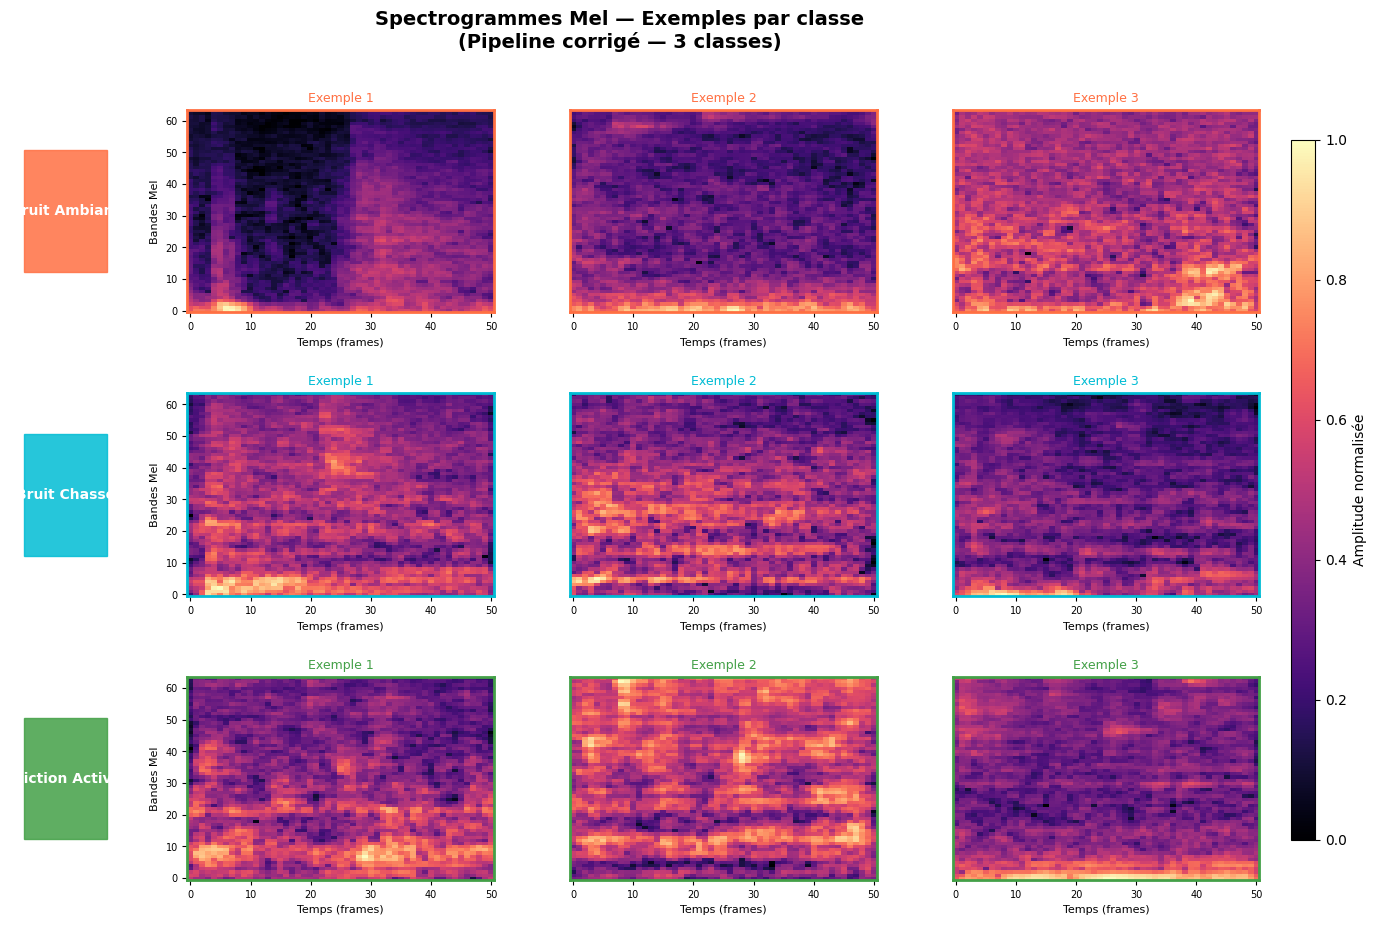

Spectrogrammes sauvegardés


In [7]:
# ════════════════════════════════════════════════════════════════
# Visualisation — Exemple de spectrogramme Mel par classe
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

classes      = ['bruit_ambiant', 'bruit_chasse', 'miction_active']
couleurs     = ['#FF7043',       '#00BCD4',       '#43A047']
noms_affich  = ['Bruit Ambiant', 'Bruit Chasse',  'Miction Active']

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Spectrogrammes Mel — Exemples par classe\n(Pipeline corrigé — 3 classes)',
             fontsize=14, fontweight='bold', y=0.98)

# Afficher 3 exemples par classe
n_exemples = 3
gs = gridspec.GridSpec(len(classes), n_exemples + 1,
                       width_ratios=[0.3] + [1]*n_exemples,
                       hspace=0.4, wspace=0.3)

for row, (lbl, couleur, nom) in enumerate(
        zip(classes, couleurs, noms_affich)):

    # Étiquette classe à gauche
    ax_label = fig.add_subplot(gs[row, 0])
    ax_label.set_xlim(0, 1)
    ax_label.set_ylim(0, 1)
    ax_label.add_patch(plt.Rectangle((0.05, 0.2), 0.9, 0.6,
                        color=couleur, alpha=0.85, zorder=2))
    ax_label.text(0.5, 0.5, nom, ha='center', va='center',
                  fontsize=10, fontweight='bold', color='white',
                  zorder=3, wrap=True)
    ax_label.axis('off')

    # Trouver des indices de cette classe dans X_train_mel
    indices_classe = [i for i, y in enumerate(y_train_enc)
                      if le.classes_[y] == lbl]

    if len(indices_classe) < n_exemples:
        print(f"⚠️ Pas assez d'exemples pour {lbl}")
        continue

    # Prendre 3 exemples espacés
    step = len(indices_classe) // n_exemples
    exemples_idx = [indices_classe[i * step] for i in range(n_exemples)]

    for col, idx_seg in enumerate(exemples_idx):
        ax = fig.add_subplot(gs[row, col + 1])
        mel = X_train_mel[idx_seg, :, :, 0]  # shape (64, 51)

        img = ax.imshow(mel, origin='lower', aspect='auto',
                        cmap='magma', vmin=0, vmax=1)

        ax.set_xlabel('Temps (frames)', fontsize=8)
        if col == 0:
            ax.set_ylabel('Bandes Mel', fontsize=8)
        else:
            ax.set_yticks([])

        ax.set_title(f'Exemple {col+1}', fontsize=9, color=couleur)
        ax.tick_params(labelsize=7)

        # Barre colorée en haut
        for spine in ax.spines.values():
            spine.set_edgecolor(couleur)
            spine.set_linewidth(2)

# Colorbar commune
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='magma',
                            norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Amplitude normalisée')

plt.savefig(f'{OUTPUT_DIR}/spectrogrammes_mel_3classes.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Spectrogrammes sauvegardés")

In [8]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 5 — ARCHITECTURE CNN 2D
# ════════════════════════════════════════════════════════════════

def build_cnn2d(input_shape=(64, 51, 1), n_classes=3):
    inputs = keras.Input(shape=input_shape)

    # Bloc 1
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.1)(x)

    # Bloc 2
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.1)(x)

    # Bloc 3
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    # Bloc 4 ← nouveau
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)  # ← nouveau
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

# Adapter input_shape à la vraie taille du spectrogramme
input_shape = X_tr.shape[1:]
print(f"Input shape CNN : {input_shape}")

model = build_cnn2d(input_shape=input_shape, n_classes=4)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

Input shape CNN : (64, 51, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 51, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 51, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 51, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 64, 51, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 25, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 25, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 25, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32, 25, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 16, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 6, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8, 6, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 8, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 488,964 (1.87 MB)

 Trainable params: 488,004 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 6 — ENTRAÎNEMENT
# ════════════════════════════════════════════════════════════════
from sklearn.utils.class_weight import compute_class_weight

# Class weights
cw = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr),
    y=y_tr)
class_weight_dict = dict(enumerate(cw))
print(f"Class weights : {class_weight_dict}")

# Modèle
input_shape = X_tr.shape[1:]
model = build_cnn2d(input_shape=input_shape, n_classes=3)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # ← learning_rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15,       # ← plus patient
        restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(
        f'{OUTPUT_DIR}/cnn2d_v2.keras',
        monitor='val_loss', save_best_only=True),
]

history = model.fit(
    X_tr, y_tr,
    epochs=100,                                # ← plus d'epochs
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weight_dict,            # ← class weights
    verbose=1)

Class weights : {0: np.float64(0.8333333333333334), 1: np.float64(1.1111111111111112), 2: np.float64(1.1111111111111112)}
Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 282ms/step - accuracy: 0.5751 - loss: 0.9187 - val_accuracy: 0.3000 - val_loss: 1.3247 - learning_rate: 5.0000e-04
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 269ms/step - accuracy: 0.7480 - loss: 0.6183 - val_accuracy: 0.3000 - val_loss: 2.6287 - learning_rate: 5.0000e-04
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step - accuracy: 0.7960 - loss: 0.5227 - val_accuracy: 0.3000 - val_loss: 2.8962 - learning_rate: 5.0000e-04
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 19s 279ms/step - accuracy: 0.8153 - loss: 0.4848 - val_accuracy: 0.3000 - val_loss: 2.7410 - learning_rate: 5.0000e-04
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 19s 278ms/step - accuracy: 0.8245 - loss: 0.4477 - val_accuracy: 0.3347 - val_loss: 2.6993 - learning_rate: 5.0000e-04
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 19s 279ms/step - accuracy: 0.8360 - loss: 0.4201 

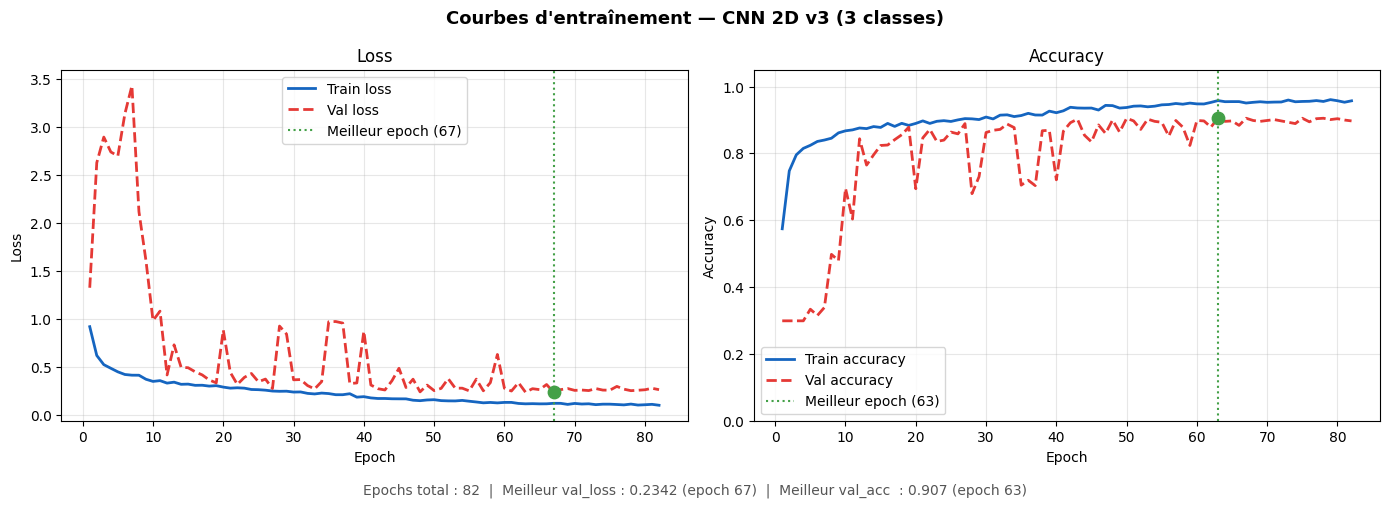

 Courbes sauvegardées
   Meilleur val_loss  : 0.2342 (epoch 67)
   Meilleur val_acc   : 0.907 (epoch 63)
   Epochs entraînés   : 82


In [17]:
# ════════════════════════════════════════════════════════════════
# Courbes d'entraînement
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'entraînement — CNN 2D v3 (3 classes)',
             fontsize=13, fontweight='bold')

epochs_range = range(1, len(history.history['loss']) + 1)

# ── Courbe Loss ───────────────────────────────────────────────
axes[0].plot(epochs_range, history.history['loss'],
             color='#1565C0', lw=2, label='Train loss')
axes[0].plot(epochs_range, history.history['val_loss'],
             color='#E53935', lw=2, linestyle='--', label='Val loss')

# Marquer le meilleur epoch
best_epoch = np.argmin(history.history['val_loss']) + 1
best_val   = min(history.history['val_loss'])
axes[0].axvline(best_epoch, color='#43A047', linestyle=':',
                lw=1.5, label=f'Meilleur epoch ({best_epoch})')
axes[0].scatter([best_epoch], [best_val],
                color='#43A047', s=80, zorder=5)

axes[0].set_title('Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Courbe Accuracy ───────────────────────────────────────────
axes[1].plot(epochs_range, history.history['accuracy'],
             color='#1565C0', lw=2, label='Train accuracy')
axes[1].plot(epochs_range, history.history['val_accuracy'],
             color='#E53935', lw=2, linestyle='--', label='Val accuracy')

best_val_acc = max(history.history['val_accuracy'])
best_ep_acc  = np.argmax(history.history['val_accuracy']) + 1
axes[1].axvline(best_ep_acc, color='#43A047', linestyle=':',
                lw=1.5, label=f'Meilleur epoch ({best_ep_acc})')
axes[1].scatter([best_ep_acc], [best_val_acc],
                color='#43A047', s=80, zorder=5)

axes[1].set_title('Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Annotations ───────────────────────────────────────────────
fig.text(0.5, 0.01,
    f'Epochs total : {len(epochs_range)}  |  '
    f'Meilleur val_loss : {best_val:.4f} (epoch {best_epoch})  |  '
    f'Meilleur val_acc  : {best_val_acc:.3f} (epoch {best_ep_acc})',
    ha='center', fontsize=10, color='#555555')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{OUTPUT_DIR}/courbes_entrainement_v3.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f" Courbes sauvegardées")
print(f"   Meilleur val_loss  : {best_val:.4f} (epoch {best_epoch})")
print(f"   Meilleur val_acc   : {best_val_acc:.3f} (epoch {best_ep_acc})")
print(f"   Epochs entraînés   : {len(epochs_range)}")

RÉSULTATS — Test set (fichiers jamais vus)
Accuracy          : 0.807
Balanced Accuracy : 0.830

                precision    recall  f1-score   support

 bruit_ambiant      0.674     0.963     0.793       135
  bruit_chasse      0.894     0.840     0.866        50
miction_active      0.970     0.686     0.804       188

      accuracy                          0.807       373
     macro avg      0.846     0.830     0.821       373
  weighted avg      0.852     0.807     0.808       373



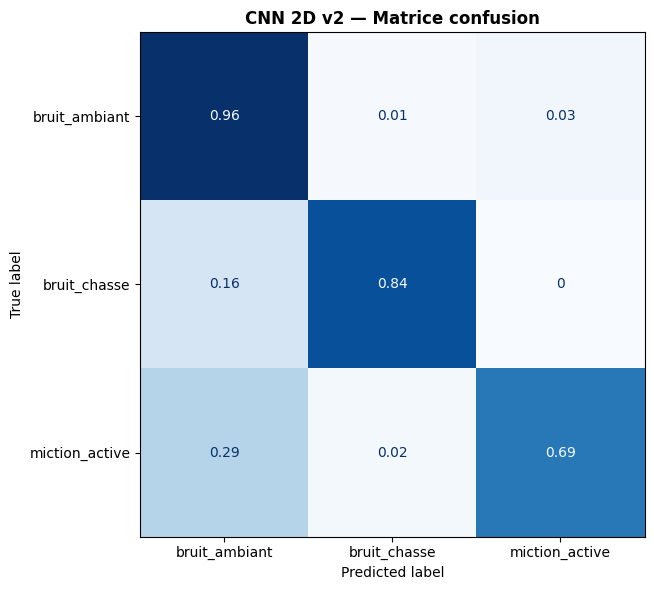


COMPARAISON
Modèle                              |  Bal.Acc
-------------------------------------------------------
CNN 2D original (leakage 4 cls)     |    0.877
CNN 2D corrigé (3 cls)              |    0.806
CNN 2D v2 amélioré (3 cls)          |    0.830


In [18]:
# ════════════════════════════════════════════════════════════════
# ÉTAPE 7 — ÉVALUATION FINALE SUR TEST (fichiers jamais vus)
# ════════════════════════════════════════════════════════════════
y_pred = np.argmax(model.predict(X_test_mel, verbose=0), axis=1)

acc = accuracy_score(y_test_enc, y_pred)
bal = balanced_accuracy_score(y_test_enc, y_pred)

print("="*60)
print("RÉSULTATS — Test set (fichiers jamais vus)")
print("="*60)
print(f"Accuracy          : {acc:.3f}")
print(f"Balanced Accuracy : {bal:.3f}")
print()
print(classification_report(
    y_test_enc, y_pred,
    target_names=['bruit_ambiant','bruit_chasse','miction_active'],
    digits=3))

# Matrice de confusion
cm      = confusion_matrix(y_test_enc, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_norm.round(2),
    display_labels=['bruit_ambiant','bruit_chasse','miction_active']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('CNN 2D v2 — Matrice confusion', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnn2d_v2_confusion.png', dpi=120)
plt.show()

print("\n" + "="*55)
print("COMPARAISON")
print("="*55)
print(f"{'Modèle':35s} | {'Bal.Acc':>8}")
print("-"*55)
print(f"{'CNN 2D original (leakage 4 cls)':35s} | {'0.877':>8}")
print(f"{'CNN 2D corrigé (3 cls)':35s} | {'0.806':>8}")
print(f"{'CNN 2D v2 amélioré (3 cls)':35s} | {bal:8.3f}")
print("="*55)

In [19]:
# ════════════════════════════════════════════════════════════════
# Fonctions de correction contextuelle
# ════════════════════════════════════════════════════════════════
from collections import Counter

def corriger_contexte(labels, fenetre=1):
    labels = list(labels)
    corrections = []
    for i in range(fenetre, len(labels) - fenetre):
        vg = labels[i - fenetre]
        vd = labels[i + fenetre]
        if vg == vd and labels[i] != vg:
            corrections.append({'avant': labels[i], 'apres': vg})
            labels[i] = vg
    return labels, corrections

def corriger_pipeline_complet(labels_pred, fenetre=1, gap=4):
    labels, corrections = corriger_contexte(labels_pred, fenetre)

    # Passe 2 — fusion trous miction 1-3 segments
    for _ in range(gap * 3):
        changed = False
        for trou in range(1, 4):
            for i in range(len(labels) - trou - 1):
                if (labels[i] == 'miction_active' and
                    labels[i + trou + 1] == 'miction_active' and
                    all(labels[i+k] != 'miction_active'
                        for k in range(1, trou + 1))):
                    for k in range(1, trou + 1):
                        labels[i + k] = 'miction_active'
                    changed = True
        if not changed:
            break

    # Passe 3 — supprimer segments isolés (vote majoritaire)
    changed = True
    while changed:
        changed = False
        for i in range(1, len(labels) - 1):
            contexte = []
            for k in range(max(0, i-2), min(len(labels), i+3)):
                if k != i:
                    contexte.append(labels[k])
            vote = max(set(contexte), key=contexte.count)
            if contexte.count(labels[i]) <= 1 and vote != labels[i]:
                labels[i] = vote
                changed = True

    return labels, corrections

Phase de correction — CNN 2D v3 — fichiers TEST uniquement
  Audio_1              : 168 segs | 13 corrections | Bal.Acc=0.685
  Audio_7              : 169 segs |  0 corrections | Bal.Acc=0.961
  Audio_5              : 175 segs |  5 corrections | Bal.Acc=0.874
  Audio_10             : 127 segs |  2 corrections | Bal.Acc=0.840
  Audio_17             : 104 segs | 17 corrections | Bal.Acc=0.954
Total segments : 743
Total corrections : 20

Métrique                  |    Avant |    Après |     Gain
-------------------------------------------------------
Accuracy                  |    0.795 |    0.820 |   +0.024
Balanced Accuracy         |    0.822 |    0.853 |   +0.031

Rapport détaillé après correction :
                precision    recall  f1-score   support

 bruit_ambiant      0.680     0.985     0.804       265
  bruit_chasse      0.928     0.891     0.909       101
miction_active      0.985     0.684     0.808       377

      accuracy                          0.820       743
     macr

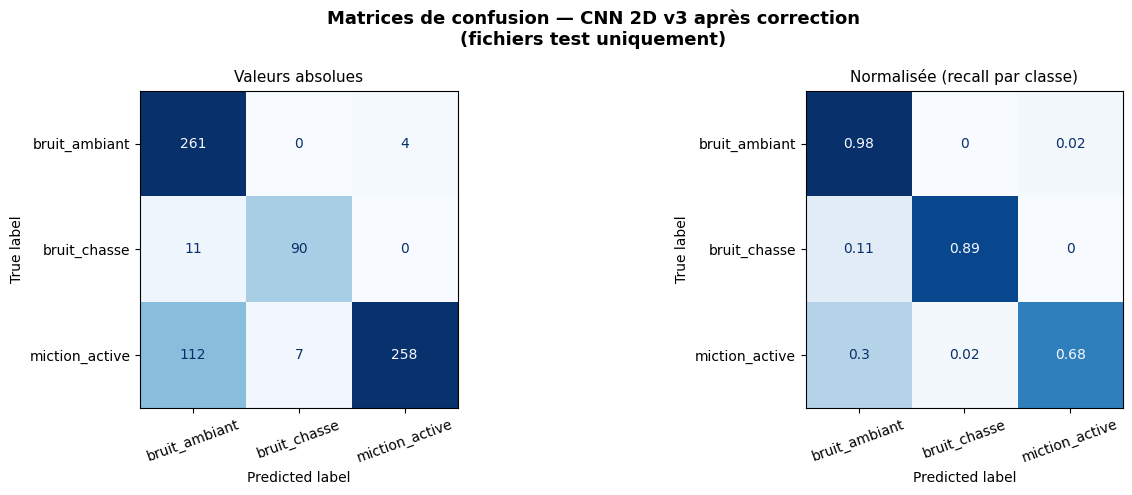


Recall par classe après correction :
  bruit_ambiant        : 0.985
  bruit_chasse         : 0.891
  miction_active       : 0.684


In [20]:
# ════════════════════════════════════════════════════════════════
# PHASE DE CORRECTION — CNN 2D v3 (3 classes, sans leakage)
# ════════════════════════════════════════════════════════════════

# ── Prédire uniquement sur les fichiers TEST ──────────────────
fichiers_test = ['Audio_1', 'Audio_7', 'Audio_5', 'Audio_10', 'Audio_17']

print("Phase de correction — CNN 2D v3 — fichiers TEST uniquement")
print("="*65)

tous_avant, tous_apres, tous_vrais = [], [], []
total_corrections = []

for nom_fichier in fichiers_test:          # ← uniquement test
    if nom_fichier not in labels_check:
        print(f"   {nom_fichier} absent de labels_check")
        continue
    if nom_fichier not in dataset:
        print(f"   {nom_fichier} absent de dataset")
        continue

    labels_orig = labels_check[nom_fichier]
    filt        = dataset[nom_fichier]['filtered']
    sr          = dataset[nom_fichier]['sr']
    n_segs_orig = len(labels_orig)

    # ── Segmenter avec chevauchement 50% ─────────────────────
    segments, labels_vrais, pos = [], [], 0
    while pos + SEG_LEN <= len(filt):
        segment  = filt[pos:pos + SEG_LEN]
        centre_s = (pos + SEG_LEN // 2) / sr
        orig_id  = min(int(centre_s / 0.5), n_segs_orig - 1)
        lbl_vrai = labels_orig[orig_id]
        if lbl_vrai == 'silence':
            lbl_vrai = 'bruit_ambiant'
        segments.append(segment)
        labels_vrais.append(lbl_vrai)
        pos += HOP_LEN_AUD

    # ── Prédire ───────────────────────────────────────────────
    X_mel_f     = np.array([signal_to_melspec(s)
                             for s in segments])[..., np.newaxis]
    probas      = model.predict(X_mel_f, verbose=0)
    labels_pred = list(le.inverse_transform(np.argmax(probas, axis=1)))
    labels_pred = ['bruit_ambiant' if l == 'silence'
                   else l for l in labels_pred]

    # ── Corriger ──────────────────────────────────────────────
    labels_corr, corrections = corriger_pipeline_complet(
        labels_pred, fenetre=1, gap=4)

    tous_avant.extend(labels_pred)
    tous_apres.extend(labels_corr)
    tous_vrais.extend(labels_vrais)
    total_corrections.extend(corrections)

    n_av  = sum(1 for a,b in zip(labels_pred, labels_corr) if a!=b)
    bal_f = balanced_accuracy_score(labels_vrais, labels_corr)
    print(f"  {nom_fichier:20s} : {len(segments):3d} segs | "
          f"{n_av:2d} corrections | Bal.Acc={bal_f:.3f}")

print("="*65)
print(f"Total segments : {len(tous_vrais)}")
print(f"Total corrections : {len(total_corrections)}")


# ── Métriques globales ────────────────────────────────────────
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

CLASSES_3 = ['bruit_ambiant', 'bruit_chasse', 'miction_active']

acc_av = accuracy_score(tous_vrais, tous_avant)
bal_av = balanced_accuracy_score(tous_vrais, tous_avant)
acc_ap = accuracy_score(tous_vrais, tous_apres)
bal_ap = balanced_accuracy_score(tous_vrais, tous_apres)

print(f"\n{'Métrique':25s} | {'Avant':>8} | {'Après':>8} | {'Gain':>8}")
print("-"*55)
print(f"{'Accuracy':25s} | {acc_av:8.3f} | {acc_ap:8.3f} | {acc_ap-acc_av:+8.3f}")
print(f"{'Balanced Accuracy':25s} | {bal_av:8.3f} | {bal_ap:8.3f} | {bal_ap-bal_av:+8.3f}")

print(f"\nRapport détaillé après correction :")
print(classification_report(
    tous_vrais, tous_apres,
    target_names=CLASSES_3, digits=3))

# ── Types de corrections ──────────────────────────────────────
transitions = Counter([f"{c['avant']} → {c['apres']}"
                        for c in total_corrections])
if transitions:
    print(f"Types de corrections :")
    for trans, count in transitions.most_common():
        print(f"  {trans:50s} : {count:3d}")

# ── Matrice de confusion ──────────────────────────────────────
cm      = confusion_matrix(tous_vrais, tous_apres, labels=CLASSES_3)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrices de confusion — CNN 2D v3 après correction\n(fichiers test uniquement)',
             fontsize=13, fontweight='bold')

ConfusionMatrixDisplay(cm, display_labels=CLASSES_3).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Valeurs absolues', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)

ConfusionMatrixDisplay(cm_norm.round(2), display_labels=CLASSES_3).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalisée (recall par classe)', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_v3_test_correction.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRecall par classe après correction :")
for i, cls in enumerate(CLASSES_3):
    print(f"  {cls:20s} : {cm_norm[i,i]:.3f}")